## Model Training

Import all libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import GridSearchCV
from sklearn import metrics

from xgboost import XGBRegressor
from xgboost import plot_importance

load dataset

In [11]:
df = pd.read_csv('../model building/final_df.csv')
df.head()

,base_price,distance_km,days_until_departure,trip_duration_minutes,number_of_stops,departure_hour,arrival_hour,is_weekend_departure,origin_YVR,origin_YYC,...,airline_route_WestJet _YOW-YYZ,airline_route_WestJet _YVR-YOW,airline_route_WestJet _YVR-YYC,airline_route_WestJet _YVR-YYZ,airline_route_WestJet _YYC-YOW,airline_route_WestJet _YYC-YVR,airline_route_WestJet _YYC-YYZ,airline_route_WestJet _YYZ-YOW,airline_route_WestJet _YYZ-YVR,airline_route_WestJet _YYZ-YYC
0,216,363,1,81,0,5,7,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,216,363,1,75,0,6,8,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,216,363,1,75,0,10,11,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,216,363,1,75,0,15,16,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,216,363,1,75,0,18,20,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df.shape

(43157, 92)

### XGBoost Model

In [13]:
# input variables
X = df.drop('base_price', axis=1)

# target variable
y = df['base_price']

Train-test split: 70-30

In [14]:
# split the dataset
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
# Define xgb as XGBRegressor with regression objective
xgb = XGBRegressor(objective='reg:squarederror', random_state=0)  # Regression loss

# Define parameters (keep as is, but increase n_estimators for better fit)
cv_params = {
    'max_depth': [4, 6],
    'min_child_weight': [3, 5],
    'learning_rate': [0.1, 0.2, 0.3],
    'n_estimators': [50, 100, 150],  # Increased from [5,10,15]
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}

# Define scoring for regression
scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2']

# Construct GridSearch
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='r2')  # Refit on R2

In [47]:
%%time
# fit the GridSearch model to training data
xgb_cv = xgb_cv.fit(x_train,y_train)
xgb_cv

CPU times: total: 7min 47s
Wall time: 47.3 s


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=0, ...),
             param_grid={'colsample_bytree': [0.7],
                         'learning_rate': [0.1, 0.2, 0.3], 'max_depth': [4, 6],
                         'min_child_weight': [3, 5],
                         'n_estimators': [50, 100, 150], 'subsample': [0.7]},
             refit='r2',
             scoring=['neg_mean_absolute_error', 'neg_mean_squared_error',
                      'r2'])

In [48]:
print("Best params:", xgb_cv.best_params_)

Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.7}


In [50]:
# Apply your model to predict on your test data. Call this output "y_pred"
best_model = xgb_cv.best_estimator_
test_pred = best_model.predict(x_test)
train_pred = best_model.predict(x_train)
print(f'Training MAE: {mean_absolute_error(y_train, train_pred):.2f}')
print(f'Training R2: {r2_score(y_train, train_pred):.3f}')

print(f'Test MAE: {mean_absolute_error(y_test, test_pred):.2f}')
print(f'Test R2: {r2_score(y_test, test_pred):.3f}')

Training MAE: 20.92
Training R2: 0.891
Test MAE: 25.24
Test R2: 0.819


<Figure size 1200x1200 with 0 Axes>

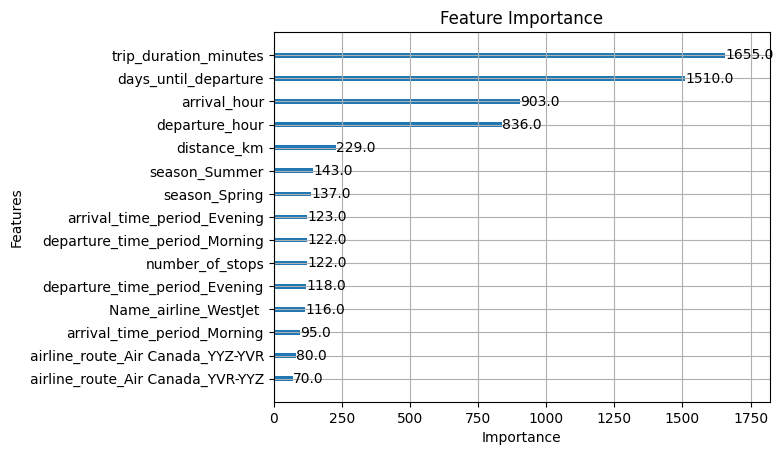

In [52]:
# Plot the relative feature importance of the predictor variables in your model.
plt.figure(figsize=(12, 12))
plot_importance(xgb_cv.best_estimator_, max_num_features=15)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

### Random Forest